# Weighted ECM clustering
## Toys dataset - 2 clusters, 2 dimensions


In [23]:
## Importing
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import numpy as np
from evclust.utils import plotting, display_results_fuzzy_partition, display_results_evidential, ev_plot_2D
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import math

from evclust.wecm_new_barycenter_2 import wecm as wecm2
from evclust.gwecm import gwecm

In [24]:
# Generating data set
# Number of points in each cluster
num_points = 200

# Number of dimensions for each point
num_dimensions = 6

# Mean and covariance matrices for each cluster
identity = np.eye(6)
cov_matrix1 = np.array([1, 8, 3, 7, 9, 4]).reshape((6, 1)) * identity
cov_matrix2 = np.array([9, 2, 10, 3, 1, 8]).reshape((6, 1)) * identity

cluster_params = [
    {"mean": [1, 1, 1, 1, 1, 1], "covariance": cov_matrix1, "label": 0},
    {"mean": [5, 12, 5, 5, 5, 12], "covariance": cov_matrix2, "label": 1},
]

# Generate data for each cluster
# data = np.concatenate([np.random.multivariate_normal(params["mean"], params["covariance"], num_points) for params in cluster_params])
dataset = np.concatenate(
    [np.column_stack((np.random.multivariate_normal(params["mean"], params["covariance"], num_points),
                      np.full((num_points, 1), params["label"]))) for params in cluster_params])

Instances 400 - Features 6 - Class 2
          0         1         2         3         4         5
0  0.009669 -3.253329 -1.710152  0.640853  6.413244 -1.914087
1  0.368213 -6.199268  0.924136  3.967396  0.091139 -0.965667
2  1.633144  1.170175 -1.648989 -2.233863  1.779579  2.119593
3  0.778043  5.554396  1.171193  0.300249  1.553417  2.107724
4  0.316925  2.223253  1.269993 -0.482043 -1.549878 -0.132768


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


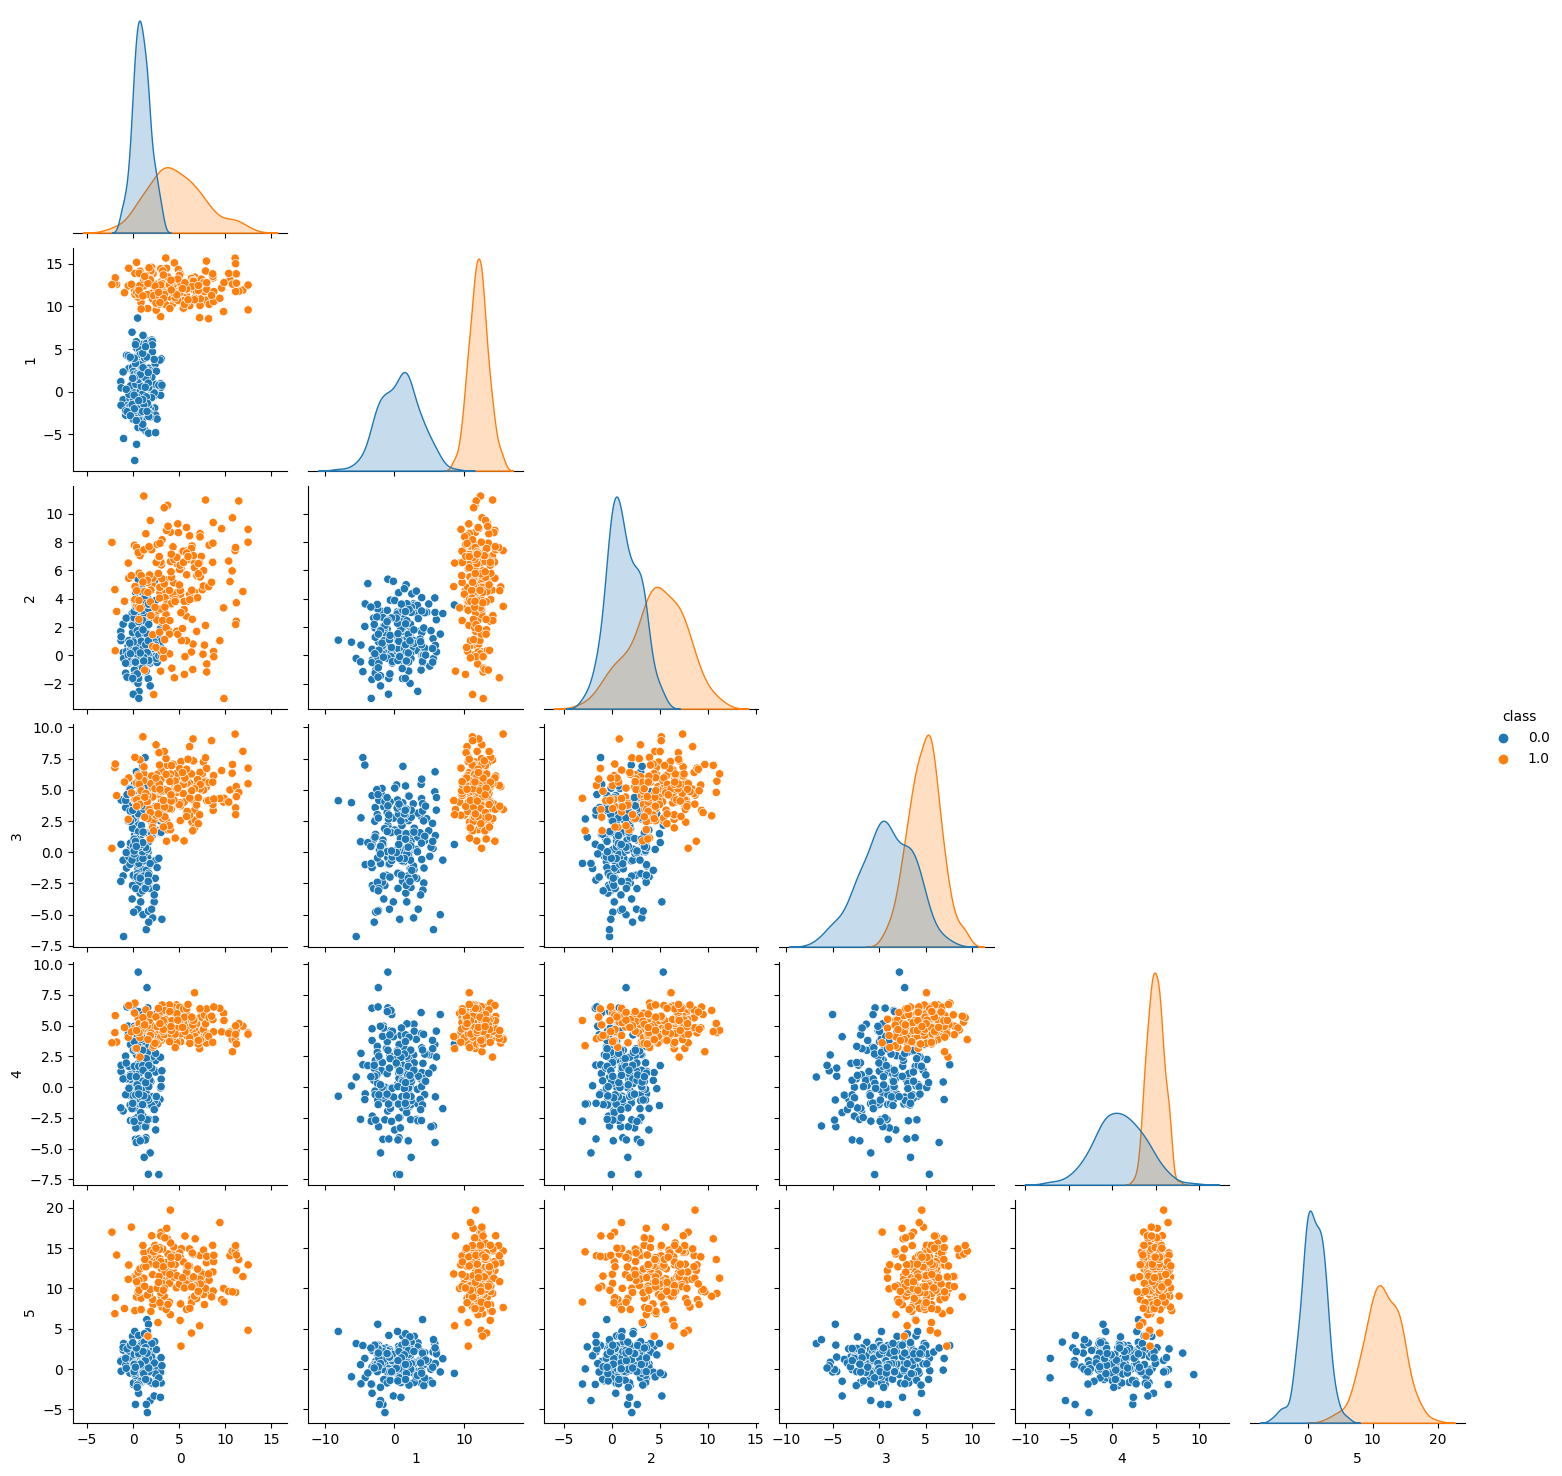

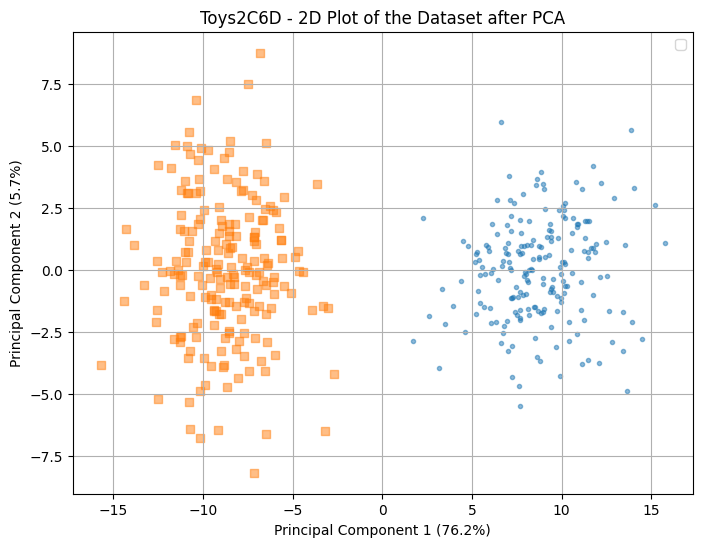

In [25]:

# df_wt_label = pd.read_csv('../../src/evclust/datasets/2dDataset.csv')
# dataset = df_wt_label.values
X = pd.DataFrame(dataset[:, :-1])
y = pd.DataFrame(dataset[:, -1])
c = 2

label_column_nm = y.columns[0]
labels_encoder = LabelEncoder()
numeric_labels = labels_encoder.fit_transform(y[label_column_nm])

# markers = ['^', 's']
plotting(X, y, "Toys2C6D", matrix_plot=True, markers=None)

# Normalization
scaler = MinMaxScaler((0,1))
X = pd.DataFrame(scaler.fit_transform(X))

In [26]:
# df = pd.DataFrame(dataset)
# df.to_csv("D:\\vtdo\projects\evclust\src\evclust\datasets\\toys3c2d.csv", index=False, header=False)

## WECM2

In [27]:
# %%capture
wecm2_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(3):
    model = wecm2(x=X, c=c, beta=2, alpha=1, delta=delta, init="None", epsilon=1e-3, stopping_factor="center")
    wecm2_models = np.append(wecm2_models, model)

wecm2_models = sorted(wecm2_models, key=lambda model: model['crit'])

Initial weights: 
 [[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]]
Initial prototypes: 
 [[0.37705456 0.74594209 0.79633016 0.89652023 0.77722587 0.65295597]
 [0.29126588 0.90030715 0.51468021 0.59152897 0.59134889 0.88332655]]
[1, 2.3990916209191493]
[2, 1.1880537190667368]
[3, 1.0592114907470842]
[4, 0.7559853945963564]
[5, 0.5697564870148241]
[6, 0.5118512966390223]
[7, 0.500283418951607]
Initial weights: 
 [[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]]
Initial prototypes: 
 [[0.42186311 0.74655668 0.22424951 0.55648875 0.64589134 0.53286563]
 [0.61912806 0.80605181 0.79344823 0.71952003 0.70135774 0.73463173]]
[1, 1.5995417411392978]
[2, 0.7851611735525192]
[3, 0.577

J values: [0.4864505557655431, 0.49401435171255886, 0.500283418951607]
ARI values: [1.0, 1.0, 1.0]
NS values: [0.7627327780790064, 0.7057938169554383, 0.7142421740544224]
NMI values: [1.0, 1.0, 1.0]


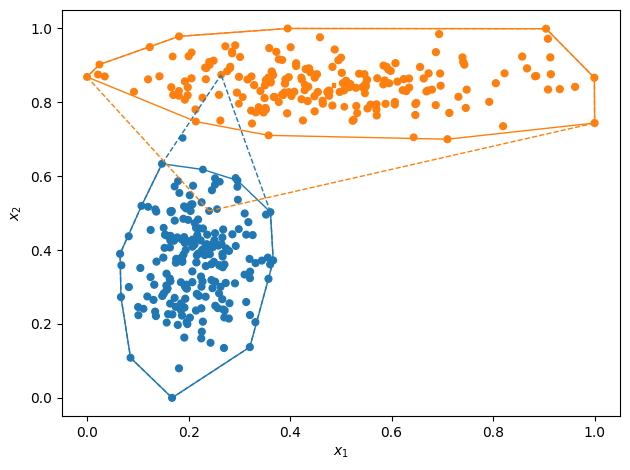

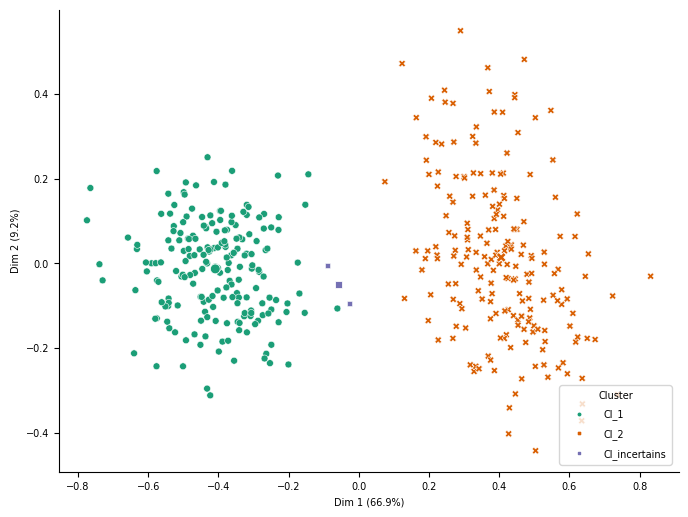

Covariance: 
 [1. 8. 3. 7. 9. 4.] 
 [ 9.  2. 10.  3.  1.  8.]
Weights: 
 [[0.37310877 0.11770033 0.11575505 0.0538649  0.05747389 0.28209707]
 [0.03063682 0.32255795 0.03208845 0.11626377 0.39369021 0.1047628 ]
 [0.39034067 0.02781781 0.16653767 0.16353292 0.11907276 0.13269817]]


In [28]:
display_results_evidential(X, wecm2_models, numeric_labels)

print(f"Covariance: \n {np.diag(cov_matrix1)} \n {np.diag(cov_matrix2)}")
print(f"Weights: \n {wecm2_models[0]['W']}")